# Feature engineering and train classic ML

## import libs

In [1]:
import h5py
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths, welch
from scipy.stats import kurtosis, skew

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor

import lightgbm as lgb
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="Set2")
plt.style.use("seaborn-v0_8-whitegrid")

## load data and set parameters

In [2]:
freq = 125  
min_bpm = 40
max_bpm = 180

DATA_DIR = Path(r"D:\datasets\PulseDB")
path = DATA_DIR / "VitalDB_Train_Subset.mat"
segment_idx = 0

with h5py.File(path, "r") as f:
    ppg = np.asarray(
        f["Subset"]["Signals"][:, 1, segment_idx],
        dtype=float
    )

ppg.shape

(1250,)

## Feature engineering

### Helper functions

In [3]:
def safe_mean(x): # среднее арифметическое
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.mean(x) if len(x) else np.nan

def integrate_area(y, x=None, dx=1.0): # площадь под кривой
    if x is None:
        return np.trapezoid(y, dx=dx)
    return np.trapezoid(y, x=x)
    
def safe_std(x): # стандартное отклонение
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.std(x) if len(x) else np.nan

def safe_min(x): # минимальное значение
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.min(x) if len(x) else np.nan

def safe_max(x): # максимальное значение
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.max(x) if len(x) else np.nan

### PPG statistics features

In [4]:
def ppg_stat_features(ppg):
    ppg = np.asarray(ppg, dtype=float)
    d1 = np.gradient(ppg) # первая производная (скорость изменения)
    d2 = np.gradient(d1) # вторая производная (ускорение)
    return {
        "ppg_mean": np.mean(ppg),
        "ppg_std": np.std(ppg),
        "ppg_min": np.min(ppg),
        "ppg_max": np.max(ppg),
        "ppg_range": np.max(ppg) - np.min(ppg),
        "ppg_median": np.median(ppg),
        "ppg_q05": np.percentile(ppg, 5),
        "ppg_q25": np.percentile(ppg, 25),
        "ppg_q75": np.percentile(ppg, 75),
        "ppg_q95": np.percentile(ppg, 95),
        "ppg_iqr": np.percentile(ppg, 75) - np.percentile(ppg, 25),
        "ppg_rms": np.sqrt(np.mean(ppg ** 2)), # среднеквадратичное значение
        "ppg_skew": skew(ppg), # асимметрия 
        "ppg_kurtosis": kurtosis(ppg), # эксцесс

        # статистика из первой производной
        "ppg_d1_mean": np.mean(d1),
        "ppg_d1_std": np.std(d1),
        "ppg_d1_min": np.min(d1),
        "ppg_d1_max": np.max(d1),
        "ppg_d1_range": np.max(d1) - np.min(d1),
        "ppg_d1_rms": np.sqrt(np.mean(d1 ** 2)),

        # статистика из второй производной
        "ppg_d2_mean": np.mean(d2),
        "ppg_d2_std": np.std(d2),
        "ppg_d2_min": np.min(d2),
        "ppg_d2_max": np.max(d2),
        "ppg_d2_range": np.max(d2) - np.min(d2),
        "ppg_d2_rms": np.sqrt(np.mean(d2 ** 2))
    }

### PPG peak PRV features

#### Базовые характеристики
- ppg_n_peaks - количество обнаруженных пиков
- ppg_peak_density - плотность пиков (количество пиков в секунду)

#### Частота сердечных сокращений
- ppg_hr_peak_bpm` - частота пульса (ударов в минуту) на основе интервалов между пиками

#### Интервалы между ударами 
- ppg_ibi_mean - средний интервал между пиками (секунды)
- ppg_ibi_std - стандартное отклонение интервалов
- ppg_ibi_min - минимальный интервал
- ppg_ibi_max - максимальный интервал
- ppg_ibi_range - размах интервалов (max - min)
- ppg_ibi_rmssd - среднеквадратичное последовательных разностей интервалов (показатель вариабельности)

#### Амплитудные характеристики пиков
- ppg_peak_amp_mean - средняя амплитуда пиков
- ppg_peak_amp_std - стандартное отклонение амплитуд
- ppg_peak_amp_min - минимальная амплитуда
- ppg_peak_amp_max - максимальная амплитуда

#### Высота пиков
- ppg_peak_prom_mean - средняя высота пиков относительно соседних впадин
- ppg_peak_prom_std - стандартное отклонение высоты пиков

#### Ширина пиков
- ppg_peak_width_mean - средняя ширина пиков в секундах
- ppg_peak_width_std - стандартное отклонение ширины пиков

In [5]:
def ppg_peak_prv_features(ppg, fs=125):
    ppg = np.asarray(ppg, dtype=float)
    peaks, props = find_peaks(ppg, distance=int(0.35 * fs), prominence=0.05)

    features = {
        "ppg_n_peaks": len(peaks),
        "ppg_peak_density": len(peaks) / (len(ppg) / fs),
    }
    if len(peaks) < 2:
        nan_features = {
            "ppg_hr_peak_bpm": np.nan,
            "ppg_ibi_mean": np.nan,
            "ppg_ibi_std": np.nan,
            "ppg_ibi_min": np.nan,
            "ppg_ibi_max": np.nan,
            "ppg_ibi_range": np.nan,
            "ppg_ibi_rmssd": np.nan,
            "ppg_peak_amp_mean": np.nan,
            "ppg_peak_amp_std": np.nan,
            "ppg_peak_amp_min": np.nan,
            "ppg_peak_amp_max": np.nan,
            "ppg_peak_prom_mean": np.nan,
            "ppg_peak_prom_std": np.nan,
            "ppg_peak_width_mean": np.nan,
            "ppg_peak_width_std": np.nan,
        }
        features.update(nan_features)
        return features
    
    ibi = np.diff(peaks) / fs # интервалы между пиками
    peak_amp = ppg[peaks] # амплитуды пиков
    prominences = props.get("prominences", np.full(len(peaks), np.nan)) # высота пиков

    widths = peak_widths(ppg, peaks, rel_height=0.5) # ширина пиков
    width_seconds = widths[0] / fs # ширина пиков в секундах

    features.update({
        "ppg_hr_peak_bpm": 60.0 / np.mean(ibi), 

        "ppg_ibi_mean": np.mean(ibi),
        "ppg_ibi_std": np.std(ibi),
        "ppg_ibi_min": np.min(ibi),
        "ppg_ibi_max": np.max(ibi),
        "ppg_ibi_range": np.max(ibi) - np.min(ibi),
        "ppg_ibi_rmssd": np.sqrt(np.mean(np.diff(ibi) ** 2)) if len(ibi) > 1 else np.nan,

        "ppg_peak_amp_mean": np.mean(peak_amp),
        "ppg_peak_amp_std": np.std(peak_amp),
        "ppg_peak_amp_min": np.min(peak_amp),
        "ppg_peak_amp_max": np.max(peak_amp),

        "ppg_peak_prom_mean": safe_mean(prominences),
        "ppg_peak_prom_std": safe_std(prominences),

        "ppg_peak_width_mean": np.mean(width_seconds),
        "ppg_peak_width_std": np.std(width_seconds),
    })

    return features

### PPG morphology features

Извлекаемые признаки пульсовой волны:

Временные характеристики (секунды):
- upstroke_time : время подъёма (от начала до систолического пика)
- decay_time : время спада (от пика до окончания волны)  
- pulse_duration : общая длительность пульсовой волны

Амплитудные характеристики:
- amp : амплитуда пульсовой волны (разница между пиком и базовой линией)
- rise_slope : скорость подъёма (амплитуда / время подъёма)
- decay_slope : скорость спада (амплитуда / время спада)

Площадные характеристики (площадь под кривой):
- pulse_area : общая площадь под пульсовой волной (вычитание базовой линии)
- systolic_area : площадь в систолической фазе (от начала до пика)
- diastolic_area : площадь в диастолической фазе (от пика до окончания)
- area_ratio : отношение диастолической площади к систолической

Морфологический признак:
- half_width : полувысотная ширина (длительность участка на уровне 50% амплитуды)


#### Обработка пульсовой волны

In [6]:
def single_pulse_features(ppg, left, peak, right, fs):
    if right <= left or peak <= left or peak >= right:
        return None

    beat = ppg[left:right + 1] # сигнал в пределах пика
    local_peak = peak - left # локальный пик

    baseline = min(ppg[left], ppg[right]) # базовая линия
    peak_value = ppg[peak] # пиковое значение
    amp = peak_value - baseline # амплитуда

    if amp <= 0:
        return None

    # временные характеристики
    up_time = (peak - left) / fs # время подъёма
    decay_time = (right - peak) / fs # время спада
    duration = (right - left) / fs # длительность

    beat_baseline = np.maximum(beat - baseline, 0) # отклонение от базовой линии

    # площадь под кривой
    pulse_area = integrate_area(beat_baseline, dx=1 / fs)
    systolic_area = integrate_area(beat_baseline[:local_peak + 1], dx=1 / fs)
    diastolic_area = integrate_area(beat_baseline[local_peak:], dx=1 / fs)

    area_ratio = (diastolic_area / systolic_area if systolic_area > 0 else np.nan) # отношение площадей

    # полувысотная ширина
    half_level = baseline + 0.5 * amp
    above = np.where(beat >= half_level)[0]
    half_width = ((above[-1] - above[0]) / fs if len(above) > 1 else np.nan)

    return {
        "upstroke_time": up_time,
        "decay_time": decay_time, 
        "pulse_duration": duration, 
        "pulse_area": pulse_area,
        "systolic_area": systolic_area,
        "diastolic_area": diastolic_area,
        "area_ratio": area_ratio,
        "half_width": half_width,
        "rise_slope": amp / up_time if up_time > 0 else np.nan,
        "decay_slope": amp / decay_time if decay_time > 0 else np.nan,
        "amp": amp,
    }

#### Агрегация признаков

In [7]:
def make_morphology_nan_features():
    keys = [
        "ppg_upstroke_time_mean",
        "ppg_upstroke_time_std",
        "ppg_decay_time_mean",
        "ppg_decay_time_std",
        "ppg_pulse_duration_mean",
        "ppg_pulse_duration_std",
        "ppg_pulse_area_mean",
        "ppg_pulse_area_std",
        "ppg_systolic_area_mean",
        "ppg_diastolic_area_mean",
        "ppg_area_ratio_mean",
        "ppg_half_width_mean",
        "ppg_half_width_std",
        "ppg_rise_slope_mean",
        "ppg_decay_slope_mean",
        "ppg_amp_mean",
        "ppg_amp_std",
    ]
    return {k: np.nan for k in keys}

def aggregate_morphology_features(beat_features):
    if len(beat_features) == 0:
        return make_morphology_nan_features()
    return {
        "ppg_upstroke_time_mean": safe_mean([x["upstroke_time"] for x in beat_features]),
        "ppg_upstroke_time_std": safe_std([x["upstroke_time"] for x in beat_features]),

        "ppg_decay_time_mean": safe_mean([x["decay_time"] for x in beat_features]),
        "ppg_decay_time_std": safe_std([x["decay_time"] for x in beat_features]),

        "ppg_pulse_duration_mean": safe_mean([x["pulse_duration"] for x in beat_features]),
        "ppg_pulse_duration_std": safe_std([x["pulse_duration"] for x in beat_features]),

        "ppg_pulse_area_mean": safe_mean([x["pulse_area"] for x in beat_features]),
        "ppg_pulse_area_std": safe_std([x["pulse_area"] for x in beat_features]),

        "ppg_systolic_area_mean": safe_mean([x["systolic_area"] for x in beat_features]),
        "ppg_diastolic_area_mean": safe_mean([x["diastolic_area"] for x in beat_features]),
        "ppg_area_ratio_mean": safe_mean([x["area_ratio"] for x in beat_features]),

        "ppg_half_width_mean": safe_mean([x["half_width"] for x in beat_features]),
        "ppg_half_width_std": safe_std([x["half_width"] for x in beat_features]),

        "ppg_rise_slope_mean": safe_mean([x["rise_slope"] for x in beat_features]),
        "ppg_decay_slope_mean": safe_mean([x["decay_slope"] for x in beat_features]),

        "ppg_amp_mean": safe_mean([x["amp"] for x in beat_features]),
        "ppg_amp_std": safe_std([x["amp"] for x in beat_features]),
    }

#### Извлечение морфологических признаков

In [8]:
def ppg_morphology_features(ppg, fs=125):
    ppg = np.asarray(ppg, dtype=float)

    peaks, _ = find_peaks(ppg, distance=int(0.35 * fs), prominence=0.05)
    troughs, _ = find_peaks(-ppg, distance=int(0.25 * fs))

    feature_keys = [
        "upstroke_time", "decay_time", "pulse_duration",
        "pulse_area", "systolic_area", "diastolic_area",
        "area_ratio", "half_width",
        "rise_slope", "decay_slope", "amp"
    ]

    if len(peaks) == 0 or len(troughs) < 2:
        return make_morphology_nan_features()

    beat_features = []

    for peak in peaks:
        left_candidates = troughs[troughs < peak]
        right_candidates = troughs[troughs > peak]

        if len(left_candidates) == 0 or len(right_candidates) == 0:
            continue

        left = left_candidates[-1]
        right = right_candidates[0]

        features = single_pulse_features(ppg, left, peak, right, fs)

        if features is not None:
            beat_features.append(features)

    return aggregate_morphology_features(beat_features)

### PPG frequency features

### Частотный анализ (метод Велча)
- ppg_fft_hr_bpm - доминирующая частота сердечных сокращений (ударов в минуту), определяемая как пик в спектре в диапазоне ЧСС
- ppg_fft_peak_power - мощность на доминирующей частоте ЧСС
- ppg_fft_hr_band_power - общая мощность в диапазоне частот ЧСС (от min_bpm до max_bpm)
- ppg_fft_total_power - общая мощность спектра во всем частотном диапазоне
- ppg_fft_hr_power_ratio - отношение мощности диапазона ЧСС к общей мощности спектра
- ppg_fft_snr - отношение сигнал/шум (мощность пика ЧСС к медианной мощности в диапазоне ЧСС)

### Спектральные мощности в физиологических диапазонах
- ppg_lf_power - мощность в низкочастотном диапазоне (0.04-0.15 Гц), отражающий симпатическую активность и барорефлекторную регуляцию
- ppg_hf_power - мощность в высокочастотном диапазоне (0.15-0.40 Гц), связанный с парасимпатической (вагусной) активностью и дыхательной аритмией
- ppg_lf_hf_ratio - отношение низкочастотной мощности к высокочастотной, показатель симпато-вагального баланса

In [9]:
def ppg_frequency_features(ppg, fs=125, min_bpm=40, max_bpm=180):
    ppg = np.asarray(ppg, dtype=float)
    ppg = ppg - np.mean(ppg)

    freqs, psd = welch(
        ppg,
        fs=fs,
        nperseg=min(len(ppg), 512)
    )

    total_power = integrate_area(psd, x=freqs)

    hr_mask = (freqs >= min_bpm / 60) & (freqs <= max_bpm / 60)

    if hr_mask.sum() > 0:
        hr_freqs = freqs[hr_mask]
        hr_psd = psd[hr_mask]

        peak_idx = np.argmax(hr_psd)
        dominant_freq = hr_freqs[peak_idx]
        peak_power = hr_psd[peak_idx]
        band_power = integrate_area(hr_psd, x=hr_freqs)

        median_power = np.median(hr_psd)
        snr = peak_power / median_power if median_power > 0 else np.nan
    else:
        dominant_freq = np.nan
        peak_power = np.nan
        band_power = np.nan
        snr = np.nan

    lf_mask = (freqs >= 0.04) & (freqs < 0.15)
    hf_mask = (freqs >= 0.15) & (freqs < 0.40)

    lf_power = integrate_area(psd[lf_mask], x=freqs[lf_mask]) if lf_mask.sum() > 1 else np.nan
    hf_power = integrate_area(psd[hf_mask], x=freqs[hf_mask]) if hf_mask.sum() > 1 else np.nan

    return {
        "ppg_fft_hr_bpm": dominant_freq * 60 if np.isfinite(dominant_freq) else np.nan,
        "ppg_fft_peak_power": peak_power,
        "ppg_fft_hr_band_power": band_power,
        "ppg_fft_total_power": total_power,
        "ppg_fft_hr_power_ratio": band_power / total_power if total_power > 0 else np.nan,
        "ppg_fft_snr": snr,

        "ppg_lf_power": lf_power,
        "ppg_hf_power": hf_power,
        "ppg_lf_hf_ratio": lf_power / hf_power if hf_power and hf_power > 0 else np.nan,
    }

### APG PPG Features

In [10]:
def ppg_apg_features(ppg, fs=125):
    ppg = np.asarray(ppg, dtype=float)

    d1 = np.gradient(ppg)
    d2 = np.gradient(d1)

    pos_peaks, _ = find_peaks(d2, distance=10)
    neg_peaks, _ = find_peaks(-d2, distance=10)

    features = {
        "apg_pos_peaks": len(pos_peaks),
        "apg_neg_peaks": len(neg_peaks),
        "apg_pos_amp_mean": safe_mean(d2[pos_peaks]) if len(pos_peaks) else np.nan,
        "apg_pos_amp_std": safe_std(d2[pos_peaks]) if len(pos_peaks) else np.nan,
        "apg_neg_amp_mean": safe_mean(d2[neg_peaks]) if len(neg_peaks) else np.nan,
        "apg_neg_amp_std": safe_std(d2[neg_peaks]) if len(neg_peaks) else np.nan,
    }

    if len(pos_peaks) >= 2:
        intervals = np.diff(pos_peaks) / fs
        features["apg_pos_interval_mean"] = np.mean(intervals)
        features["apg_pos_interval_std"] = np.std(intervals)
    else:
        features["apg_pos_interval_mean"] = np.nan
        features["apg_pos_interval_std"] = np.nan

    if len(neg_peaks) >= 2:
        intervals = np.diff(neg_peaks) / fs
        features["apg_neg_interval_mean"] = np.mean(intervals)
        features["apg_neg_interval_std"] = np.std(intervals)
    else:
        features["apg_neg_interval_mean"] = np.nan
        features["apg_neg_interval_std"] = np.nan

    return features

### Extract features

In [11]:
def extract_ppg_only_features(ppg, fs=125):
    features = {}
    features.update(ppg_stat_features(ppg))
    features.update(ppg_peak_prv_features(ppg, fs=fs))
    features.update(ppg_morphology_features(ppg, fs=fs))
    features.update(ppg_frequency_features(ppg, fs=fs))
    features.update(ppg_apg_features(ppg, fs=fs))
    return features

rows = []
with h5py.File(DATA_DIR / "VitalDB_Train_Subset.mat", "r") as f:
    subset = f["Subset"]
    for segment_idx in range(50000):
        if segment_idx % 10000 == 0:
            print(f"Processing segment {segment_idx}/{50000}")
        ppg = np.asarray(subset["Signals"][:, 1, segment_idx], dtype=float)
        feats = extract_ppg_only_features(ppg, fs=125)
        
        feats["segment_idx"] = segment_idx
        feats["SBP"] = float(subset["SBP"][0, segment_idx])
        feats["DBP"] = float(subset["DBP"][0, segment_idx])

        rows.append(feats)

features_data = pd.DataFrame(rows)
features_data.head()

Processing segment 0/50000
Processing segment 10000/50000
Processing segment 20000/50000
Processing segment 30000/50000
Processing segment 40000/50000


,ppg_mean,ppg_std,ppg_min,ppg_max,ppg_range,ppg_median,ppg_q05,ppg_q25,ppg_q75,ppg_q95,...,apg_pos_amp_std,apg_neg_amp_mean,apg_neg_amp_std,apg_pos_interval_mean,apg_pos_interval_std,apg_neg_interval_mean,apg_neg_interval_std,segment_idx,SBP,DBP
0,0.379704,0.283524,0.0,1.0,1.0,0.332331,0.045672,0.120532,0.593066,0.902644,...,0.001869,-0.002639,0.003034,0.261474,0.047047,0.254947,0.051754,0,130.705807,87.991244
1,0.361704,0.291901,0.0,1.0,1.0,0.300455,0.030475,0.106439,0.574437,0.915978,...,0.001953,-0.002213,0.002975,0.229767,0.074436,0.224182,0.073924,1,129.738382,89.147989
2,0.360977,0.279344,0.0,1.0,1.0,0.282349,0.069011,0.120533,0.561687,0.900965,...,0.001772,-0.002491,0.002858,0.254154,0.068877,0.252632,0.065935,2,131.321428,83.794773
3,0.348496,0.292843,0.0,1.0,1.0,0.280007,0.021367,0.093101,0.559737,0.906911,...,0.001811,-0.002822,0.003219,0.252923,0.035529,0.247200,0.039184,3,157.716530,104.949780
4,0.328269,0.306472,0.0,1.0,1.0,0.228701,0.023301,0.069134,0.526254,0.950601,...,0.002245,-0.002286,0.003346,0.214261,0.082127,0.215130,0.079725,4,123.773013,76.922314


In [12]:
features_data.shape

(50000, 82)

In [14]:
features_data.isna().mean().sort_values(ascending=False).head(20)

ppg_lf_power       1.0
ppg_lf_hf_ratio    1.0
ppg_hf_power       1.0
ppg_min            0.0
ppg_range          0.0
ppg_median         0.0
ppg_q05            0.0
ppg_max            0.0
ppg_q75            0.0
ppg_q95            0.0
ppg_iqr            0.0
ppg_rms            0.0
ppg_skew           0.0
ppg_kurtosis       0.0
ppg_d1_mean        0.0
ppg_q25            0.0
ppg_mean           0.0
ppg_std            0.0
ppg_d1_max         0.0
ppg_d1_min         0.0
dtype: float64

In [15]:
features_data = features_data.drop(
    columns=["ppg_lf_power", "ppg_hf_power", "ppg_lf_hf_ratio"],
    errors="ignore"
)

In [16]:
features_data.isna().mean().sort_values(ascending=False).head(20)

ppg_mean        0.0
ppg_std         0.0
ppg_min         0.0
ppg_max         0.0
ppg_range       0.0
ppg_median      0.0
ppg_q05         0.0
ppg_q25         0.0
ppg_q75         0.0
ppg_q95         0.0
ppg_iqr         0.0
ppg_rms         0.0
ppg_skew        0.0
ppg_kurtosis    0.0
ppg_d1_mean     0.0
ppg_d1_std      0.0
ppg_d1_min      0.0
ppg_d1_max      0.0
ppg_d1_range    0.0
ppg_d1_rms      0.0
dtype: float64

In [17]:
features_data.to_csv(DATA_DIR / "ppg_features_50000.csv", index=False)

## Train regression models 

In [18]:
target_cols = ["SBP", "DBP"]
drop_cols = ["SBP", "DBP", "segment_idx"]

if "Subject" in features_data.columns:
    drop_cols.append("Subject")

X = features_data.drop(columns=drop_cols, errors="ignore")
y = features_data[target_cols]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X.shape, y.shape

((50000, 76), (50000, 2))

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_val.shape

((40000, 76), (10000, 76))

C:\Users\_\AppData\Local\Temp\ipykernel_7888\4186866938.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train)


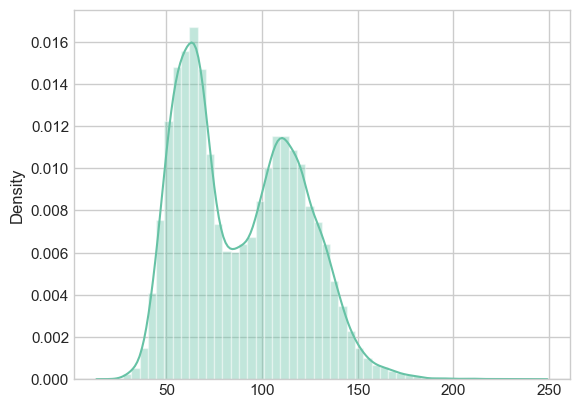

In [20]:
sns.distplot(y_train)
plt.show()

### Random Forest

In [21]:
model = RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_val)

print("Model SBP MAE:", mean_absolute_error(y_val["SBP"], pred[:, 0]))
print("Model DBP MAE:", mean_absolute_error(y_val["DBP"], pred[:, 1]))

print("Model SBP RMSE:", mean_squared_error(y_val["SBP"], pred[:, 0]) ** 0.5)
print("Model DBP RMSE:", mean_squared_error(y_val["DBP"], pred[:, 1]) ** 0.5)

print("Model SBP ME:", np.mean(pred[:, 0] - y_val["SBP"].values))
print("Model DBP ME:", np.mean(pred[:, 1] - y_val["DBP"].values))

Model SBP MAE: 9.65184806621158
Model DBP MAE: 6.468527578988726
Model SBP RMSE: 12.896991719988554
Model DBP RMSE: 8.583448863732693
Model SBP ME: 0.005871945196660923
Model DBP ME: 0.004834581564245018


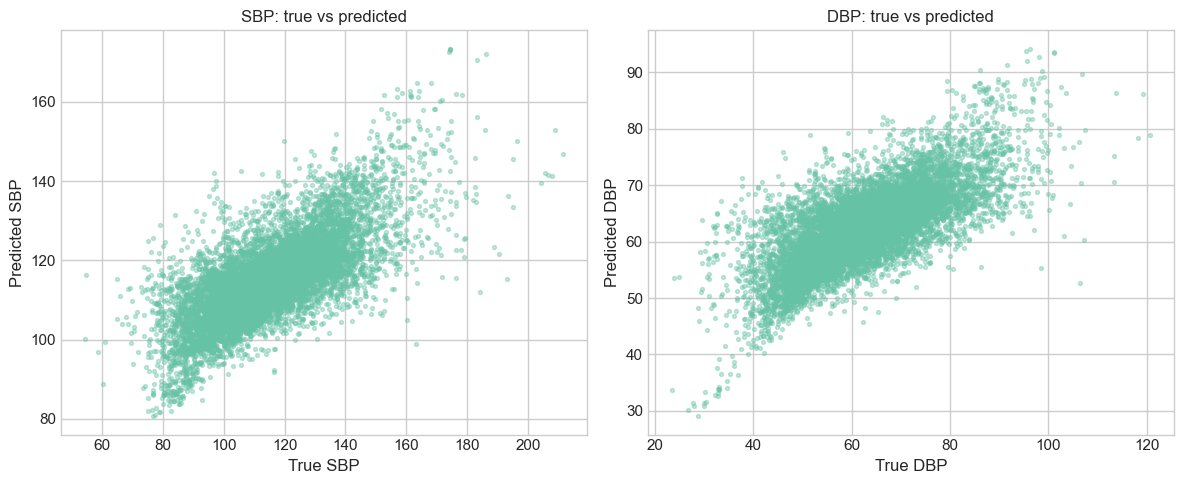

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_val["SBP"], pred[:, 0], s=8, alpha=0.4)
axes[0].set_xlabel("True SBP")
axes[0].set_ylabel("Predicted SBP")
axes[0].set_title("SBP: true vs predicted")

axes[1].scatter(y_val["DBP"], pred[:, 1], s=8, alpha=0.4)
axes[1].set_xlabel("True DBP")
axes[1].set_ylabel("Predicted DBP")
axes[1].set_title("DBP: true vs predicted")

plt.tight_layout()
plt.show()

In [23]:
sbp_model = model.estimators_[0]
dbp_model = model.estimators_[1]

feature_importance = pd.DataFrame({"feature": X.columns, "SBP_importance": sbp_model.feature_importances_, "DBP_importance": dbp_model.feature_importances_,})
feature_importance["mean_importance"] = (feature_importance["SBP_importance"] + feature_importance["DBP_importance"]) / 2
feature_importance = feature_importance.sort_values("mean_importance", ascending=False)

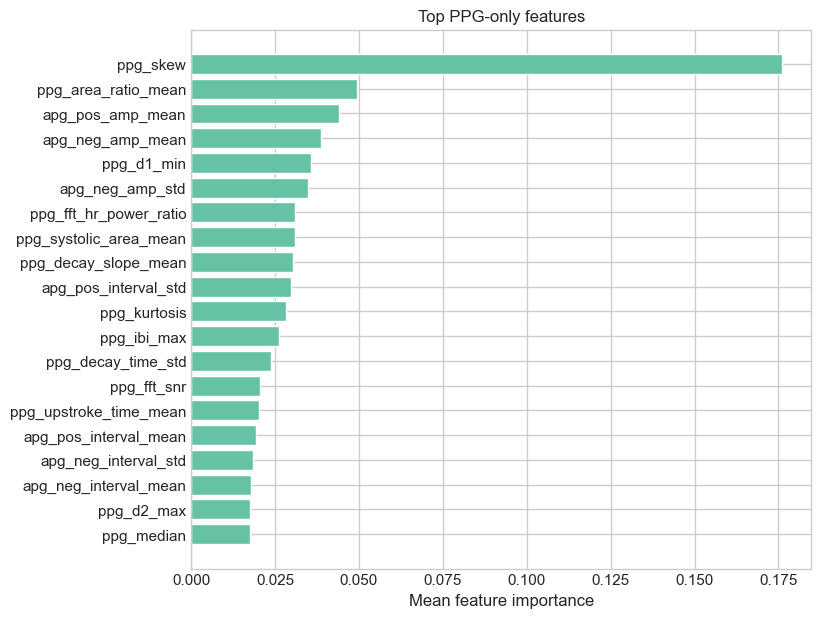

In [24]:
top = feature_importance.head(20).iloc[::-1]

plt.figure(figsize=(8, 7))
plt.barh(top["feature"], top["mean_importance"])
plt.xlabel("Mean feature importance")
plt.title("Top PPG-only features")
plt.show()

### XGBoost

In [25]:
xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1
    )
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

print("XGBoost SBP MAE:", mean_absolute_error(y_val["SBP"], xgb_pred[:, 0]))
print("XGBoost DBP MAE:", mean_absolute_error(y_val["DBP"], xgb_pred[:, 1]))

print("XGBoost SBP RMSE:", mean_squared_error(y_val["SBP"], xgb_pred[:, 0]) ** 0.5)
print("XGBoost DBP RMSE:", mean_squared_error(y_val["DBP"], xgb_pred[:, 1]) ** 0.5)

print("XGBoost SBP ME:", np.mean(xgb_pred[:, 0] - y_val["SBP"].values))
print("XGBoost DBP ME:", np.mean(xgb_pred[:, 1] - y_val["DBP"].values))


XGBoost SBP MAE: 7.816428805223976
XGBoost DBP MAE: 4.837447302595842
XGBoost SBP RMSE: 10.917614952597734
XGBoost DBP RMSE: 6.808602299054967
XGBoost SBP ME: 0.013272362333050956
XGBoost DBP ME: -0.019642087654089528


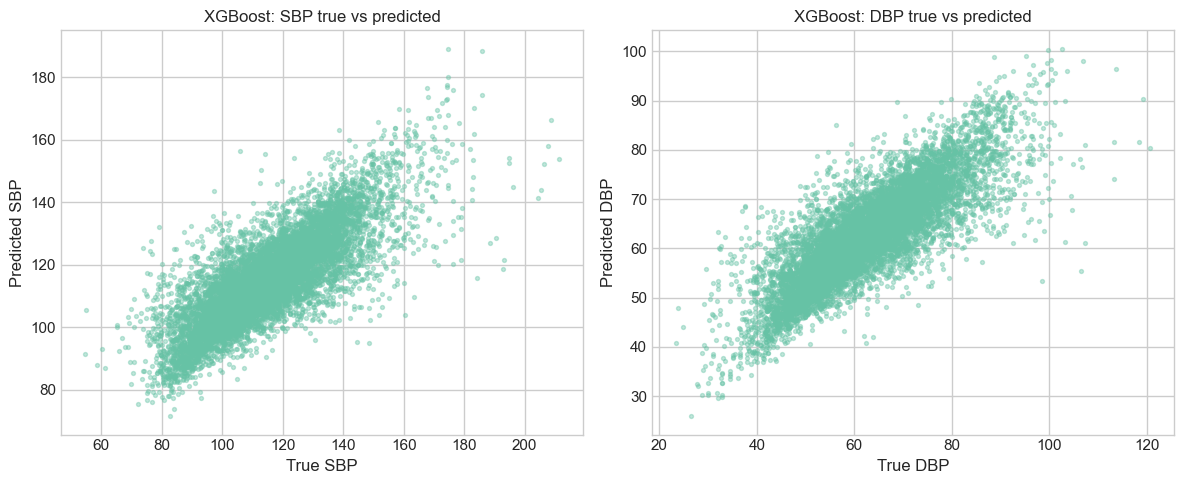

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_val["SBP"], xgb_pred[:, 0], s=8, alpha=0.4)
axes[0].set_xlabel("True SBP")
axes[0].set_ylabel("Predicted SBP")
axes[0].set_title("XGBoost: SBP true vs predicted")
axes[1].scatter(y_val["DBP"], xgb_pred[:, 1], s=8, alpha=0.4)
axes[1].set_xlabel("True DBP")
axes[1].set_ylabel("Predicted DBP")
axes[1].set_title("XGBoost: DBP true vs predicted")

plt.tight_layout()
plt.show()

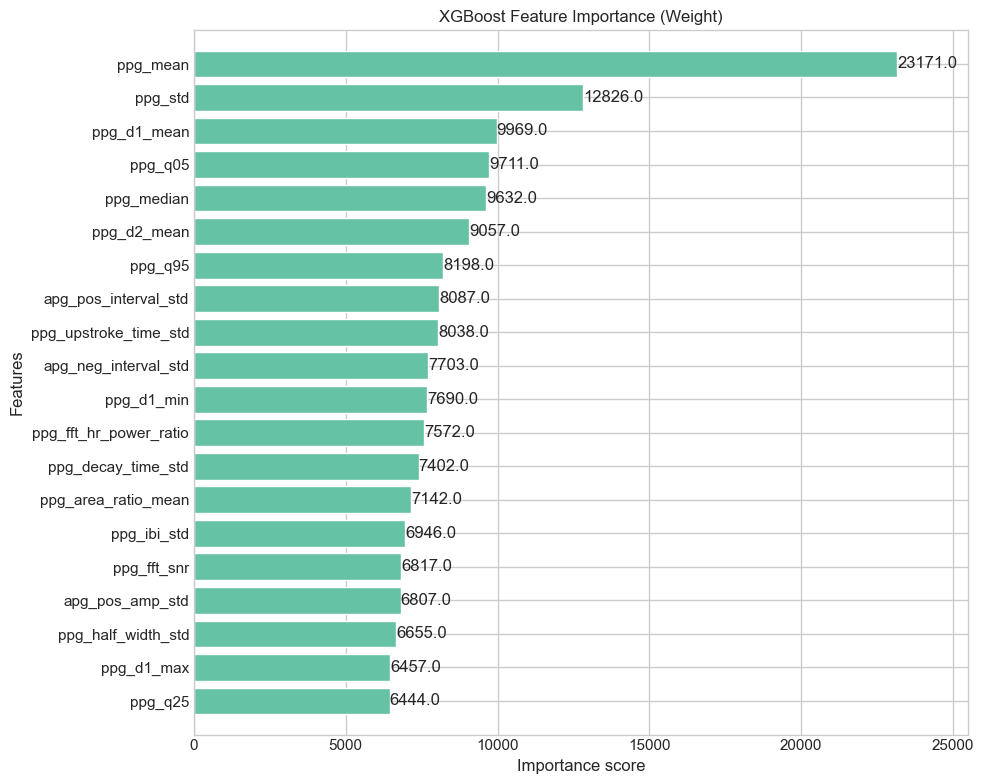

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xgb_model, 
                    importance_type='weight',  # 'weight', 'gain', 'cover', 'total_gain'
                    max_num_features=20,
                    ax=ax,
                    height=0.8)
plt.title("XGBoost Feature Importance (Weight)")
plt.tight_layout()
plt.show()

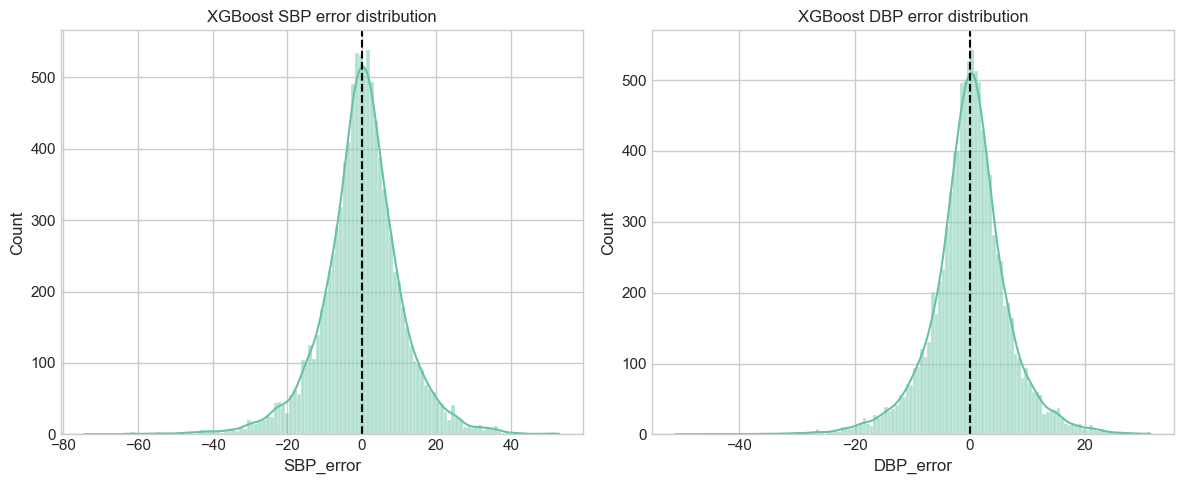

In [37]:
errors = pd.DataFrame({
    "SBP_error": xgb_pred[:, 0] - y_val["SBP"].values,
    "DBP_error": xgb_pred[:, 1] - y_val["DBP"].values,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(errors["SBP_error"], kde=True, ax=axes[0])
sns.histplot(errors["DBP_error"], kde=True, ax=axes[1])
axes[0].axvline(0, color="black", linestyle="--")
axes[1].axvline(0, color="black", linestyle="--")
axes[0].set_title("XGBoost SBP error distribution")
axes[1].set_title("XGBoost DBP error distribution")
plt.tight_layout()
plt.show()

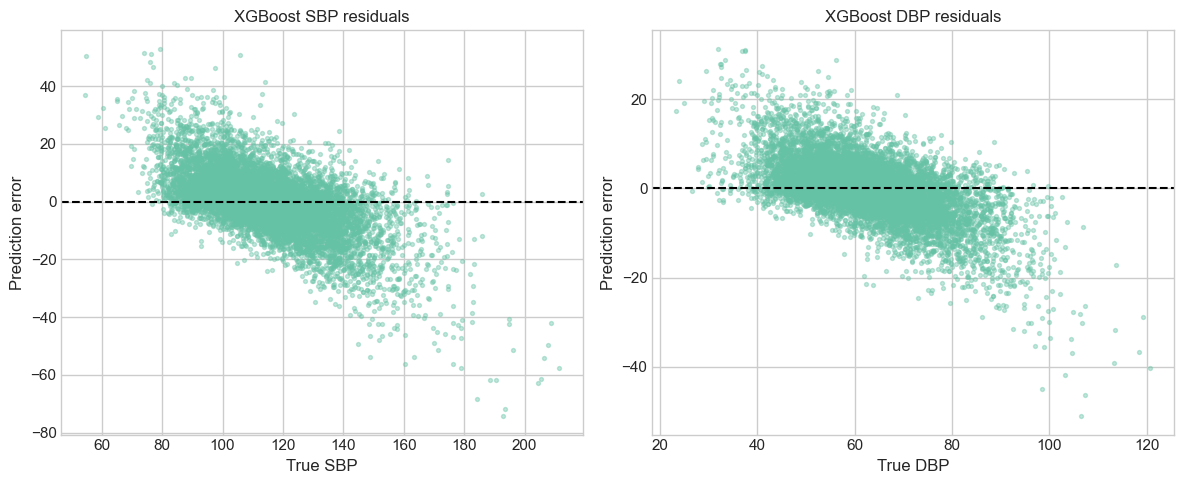

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_val["SBP"], errors["SBP_error"], s=8, alpha=0.4)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("True SBP")
axes[0].set_ylabel("Prediction error")
axes[0].set_title("XGBoost SBP residuals")

axes[1].scatter(y_val["DBP"], errors["DBP_error"], s=8, alpha=0.4)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("True DBP")
axes[1].set_ylabel("Prediction error")
axes[1].set_title("XGBoost DBP residuals")

plt.tight_layout()
plt.show()

### LightGBM

In [28]:
lgb_base_model = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    objective="regression"
)

lgb_model = MultiOutputRegressor(lgb_base_model)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_val)

print("LightGBM SBP MAE:", mean_absolute_error(y_val["SBP"], lgb_pred[:, 0]))
print("LightGBM DBP MAE:", mean_absolute_error(y_val["DBP"], lgb_pred[:, 1]))

print("LightGBM SBP RMSE:", mean_squared_error(y_val["SBP"], lgb_pred[:, 0]) ** 0.5)
print("LightGBM DBP RMSE:", mean_squared_error(y_val["DBP"], lgb_pred[:, 1]) ** 0.5)

print("LightGBM SBP ME:", np.mean(lgb_pred[:, 0] - y_val["SBP"].values))
print("LightGBM DBP ME:", np.mean(lgb_pred[:, 1] - y_val["DBP"].values))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17235
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 73
[LightGBM] [Info] Start training from score 115.586832
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17235
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 73
[LightGBM] [Info] Start training from score 62.875226
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM SBP MAE: 8.030858084668878
LightGBM DBP MAE: 5.025772976112702
LightGBM SBP RMSE: 11.014378175469371
LightGBM DBP RMSE: 6.966952298280297
LightGBM SBP M

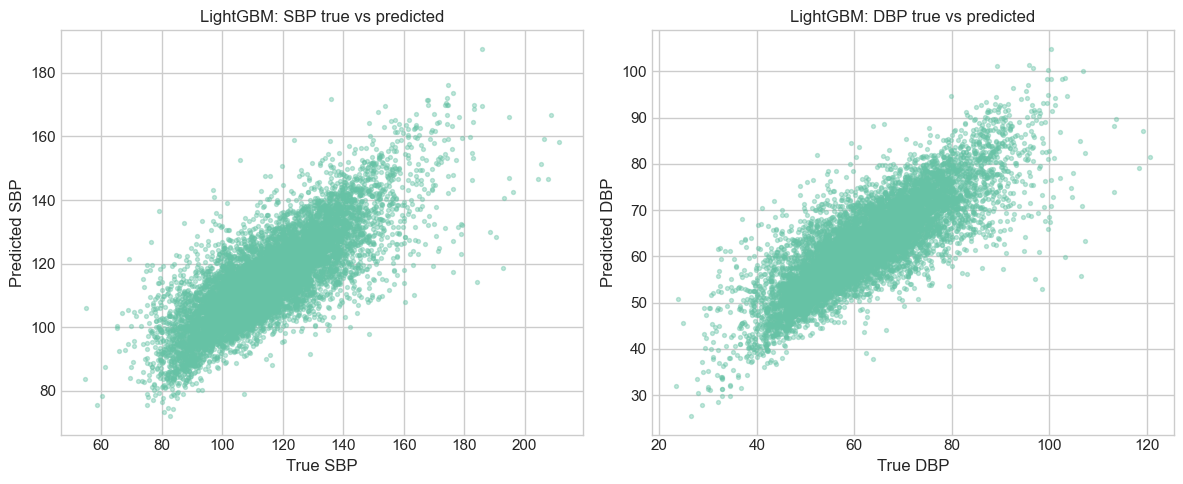

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_val["SBP"], lgb_pred[:, 0], s=8, alpha=0.4)
axes[0].set_xlabel("True SBP")
axes[0].set_ylabel("Predicted SBP")
axes[0].set_title("LightGBM: SBP true vs predicted")
axes[1].scatter(y_val["DBP"], lgb_pred[:, 1], s=8, alpha=0.4)
axes[1].set_xlabel("True DBP")
axes[1].set_ylabel("Predicted DBP")
axes[1].set_title("LightGBM: DBP true vs predicted")

plt.tight_layout()
plt.show()

### SVM

In [30]:
svr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10.0,
        epsilon=0.1,
        gamma="scale"
    ))
])

svr_model = MultiOutputRegressor(svr_base, n_jobs=-1)

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_val)

print("SVR SBP MAE:", mean_absolute_error(y_val["SBP"], svr_pred[:, 0]))
print("SVR DBP MAE:", mean_absolute_error(y_val["DBP"], svr_pred[:, 1]))

print("SVR SBP RMSE:", mean_squared_error(y_val["SBP"], svr_pred[:, 0]) ** 0.5)
print("SVR DBP RMSE:", mean_squared_error(y_val["DBP"], svr_pred[:, 1]) ** 0.5)

print("SVR SBP ME:", np.mean(svr_pred[:, 0] - y_val["SBP"].values))
print("SVR DBP ME:", np.mean(svr_pred[:, 1] - y_val["DBP"].values))

print("SVR SBP SD Error:", np.std(svr_pred[:, 0] - y_val["SBP"].values))
print("SVR DBP SD Error:", np.std(svr_pred[:, 1] - y_val["DBP"].values))

SVR SBP MAE: 9.478078271465264
SVR DBP MAE: 5.751647864408554
SVR SBP RMSE: 12.91614789743433
SVR DBP RMSE: 7.961490897829304
SVR SBP ME: -0.482528852085835
SVR DBP ME: -0.1908586664910048
SVR SBP SD Error: 12.90713145572253
SVR DBP SD Error: 7.959202867476375


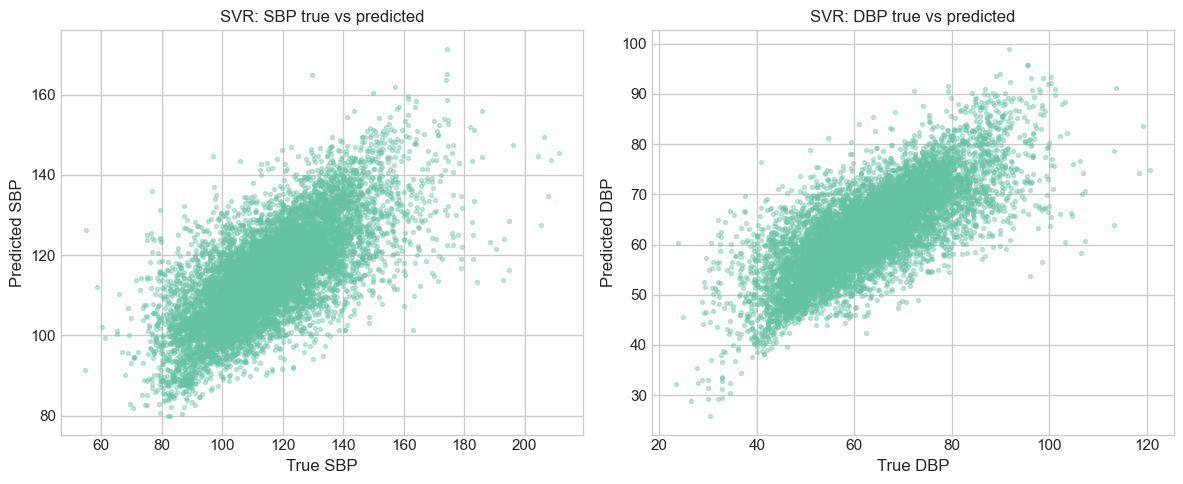

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_val["SBP"], svr_pred[:, 0], s=8, alpha=0.4)
axes[0].set_xlabel("True SBP")
axes[0].set_ylabel("Predicted SBP")
axes[0].set_title("SVR: SBP true vs predicted")
axes[1].scatter(y_val["DBP"], svr_pred[:, 1], s=8, alpha=0.4)
axes[1].set_xlabel("True DBP")
axes[1].set_ylabel("Predicted DBP")
axes[1].set_title("SVR: DBP true vs predicted")

plt.tight_layout()
plt.show()

### Вывод по классическим алгоритмам

Важное уточнение: обучение проводилось на 50.000/465480 сегментах PPG-сигнала

| algorithm     |   SBP_MAE |   DBP_MAE |
| ------------- | --------: | --------: |
| XGBoost       | **7.816** | **4.837** |
| LightGBM      |     8.031 |     5.026 |
| SVM           |     9.478 |     5.752 |
| Random Forest |     9.652 |     6.469 |


По результатам сравнительного анализа классических алгоритмов регрессии установлено, что наилучшее качество прогнозирования систолического и диастолического артериального давления демонстрирует модель XGBoost

Таким образом, среди рассмотренных классических алгоритмов наиболее предпочтительной моделью является XGBoost, обеспечивающая минимальные значения MAE как для SBP, так и для DBP. Полученные результаты позволяют рассматривать XGBoost в качестве основной классической baseline-модели для последующего сравнения с нейросетевыми подходами, основанными на rPPG-сигналах, извлекаемых из видео лица.

## Тестирование XGBoost на VitalDB_AAMI_Test_Subset

In [46]:
rows = []

with h5py.File(DATA_DIR / "VitalDB_AAMI_Test_Subset.mat", "r") as f:
    subset = f["Subset"]
    
    signals = subset["Signals"]
    n_segments = signals.shape[2]

    print("Signals shape:", signals.shape)
    print("Number of segments:", n_segments)

    for segment_idx in range(n_segments):
        if segment_idx % 100 == 0:
            print(f"Processing segment {segment_idx}/{n_segments}")

        ppg = np.asarray(signals[:, 1, segment_idx], dtype=float)
        feats = extract_ppg_only_features(ppg, fs=125)

        feats["segment_idx"] = segment_idx
        feats["SBP"] = float(subset["SBP"][0, segment_idx])
        feats["DBP"] = float(subset["DBP"][0, segment_idx])

        rows.append(feats)

features_data_test = pd.DataFrame(rows)
features_data_test.head()

Signals shape: (1250, 3, 666)
Number of segments: 666
Processing segment 0/666
Processing segment 100/666
Processing segment 200/666
Processing segment 300/666
Processing segment 400/666
Processing segment 500/666
Processing segment 600/666


,ppg_mean,ppg_std,ppg_min,ppg_max,ppg_range,ppg_median,ppg_q05,ppg_q25,ppg_q75,ppg_q95,...,apg_pos_amp_std,apg_neg_amp_mean,apg_neg_amp_std,apg_pos_interval_mean,apg_pos_interval_std,apg_neg_interval_mean,apg_neg_interval_std,segment_idx,SBP,DBP
0,0.262015,0.273693,0.0,1.0,1.0,0.135791,0.024566,0.098630,0.327531,0.918166,...,0.002448,-0.002780,0.004603,0.188615,0.048898,0.187846,0.039207,0,99.987120,57.966649
1,0.274260,0.276886,0.0,1.0,1.0,0.143380,0.030078,0.108269,0.346271,0.923775,...,0.002601,-0.002942,0.004864,0.187846,0.047445,0.187692,0.043180,1,100.759058,58.320482
2,0.266483,0.270170,0.0,1.0,1.0,0.137821,0.040874,0.097341,0.335279,0.900882,...,0.002485,-0.003001,0.004695,0.201469,0.047855,0.197600,0.038740,2,102.019124,59.022303
3,0.252831,0.272196,0.0,1.0,1.0,0.127748,0.037072,0.084101,0.309944,0.905425,...,0.002575,-0.002895,0.004661,0.187321,0.050127,0.192157,0.040622,3,102.834648,59.802165
4,0.269468,0.266801,0.0,1.0,1.0,0.147840,0.036217,0.112514,0.322766,0.905929,...,0.002448,-0.002695,0.004579,0.194196,0.056592,0.190462,0.045147,4,100.265742,58.068798


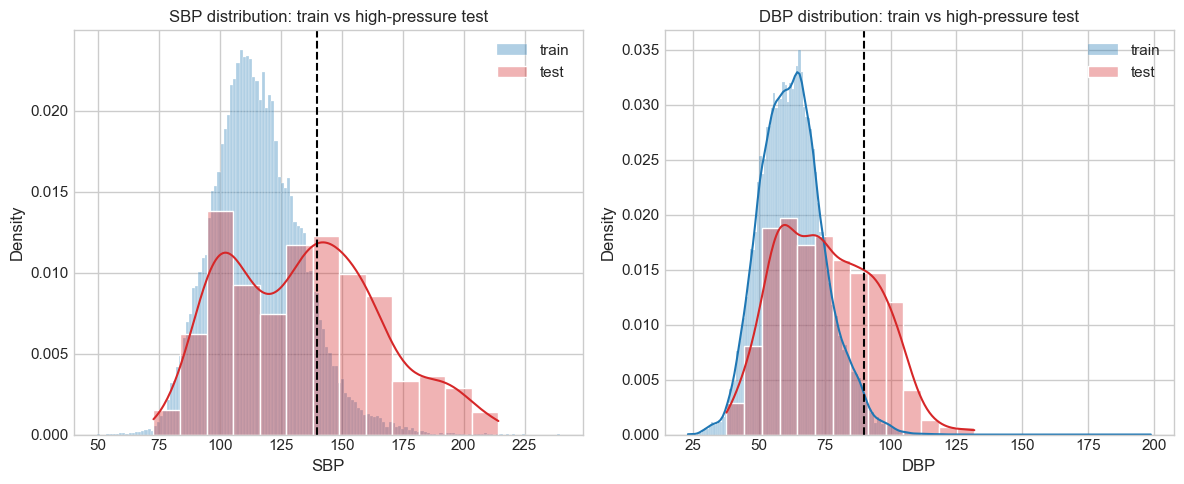

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(features_data["SBP"], label="train", color="tab:blue", alpha=0.35, stat="density", ax=axes[0])
sns.histplot(features_data_test["SBP"], label="test", color="tab:red", alpha=0.35, kde=True, stat="density", ax=axes[0])
axes[0].axvline(140, color="black", linestyle="--")
axes[0].set_title("SBP distribution: train vs high-pressure test")
axes[0].legend()

sns.histplot(features_data["DBP"], label="train", color="tab:blue", alpha=0.35, kde=True, stat="density", ax=axes[1])
sns.histplot(features_data_test["DBP"], label="test", color="tab:red",alpha=0.35, kde=True, stat="density", ax=axes[1])
axes[1].axvline(90, color="black", linestyle="--")
axes[1].set_title("DBP distribution: train vs high-pressure test")
axes[1].legend()

plt.tight_layout()
plt.show()

Дополнительная тестовая выборка из 666 сегментов имеет выраженный сдвиг распределения целевых переменных в сторону повышенного артериального давления.

In [69]:
features_data_test.isna().mean().sort_values(ascending=False).head(20)

ppg_mean        0.0
ppg_std         0.0
ppg_min         0.0
ppg_max         0.0
ppg_range       0.0
ppg_median      0.0
ppg_q05         0.0
ppg_q25         0.0
ppg_q75         0.0
ppg_q95         0.0
ppg_iqr         0.0
ppg_rms         0.0
ppg_skew        0.0
ppg_kurtosis    0.0
ppg_d1_mean     0.0
ppg_d1_std      0.0
ppg_d1_min      0.0
ppg_d1_max      0.0
ppg_d1_range    0.0
ppg_d1_rms      0.0
dtype: float64

In [70]:
features_data_test = features_data_test.drop(
    columns=["ppg_lf_power", "ppg_hf_power", "ppg_lf_hf_ratio"],
    errors="ignore"
)

In [77]:
features_data_test.isna().mean().sort_values(ascending=False).head(20)

ppg_mean        0.0
ppg_std         0.0
ppg_min         0.0
ppg_max         0.0
ppg_range       0.0
ppg_median      0.0
ppg_q05         0.0
ppg_q25         0.0
ppg_q75         0.0
ppg_q95         0.0
ppg_iqr         0.0
ppg_rms         0.0
ppg_skew        0.0
ppg_kurtosis    0.0
ppg_d1_mean     0.0
ppg_d1_std      0.0
ppg_d1_min      0.0
ppg_d1_max      0.0
ppg_d1_range    0.0
ppg_d1_rms      0.0
dtype: float64

In [82]:
target_cols = ["SBP", "DBP"]
drop_cols = ["SBP", "DBP", "segment_idx"]

if "Subject" in features_data_test.columns:
    drop_cols.append("Subject")

X_test = features_data_test.drop(columns=drop_cols, errors="ignore")
y_test = features_data_test[target_cols]

train_features = xgb_model.get_booster().feature_names

X_test = X_test.reindex(columns=train_features)

X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.fillna(X_train[train_features].median(numeric_only=True))

xgb_test_pred = xgb_model.predict(X_test)

print("XGBoost TEST SBP MAE:", mean_absolute_error(y_test["SBP"], xgb_test_pred[:, 0]))
print("XGBoost TEST DBP MAE:", mean_absolute_error(y_test["DBP"], xgb_test_pred[:, 1]))

print("XGBoost TEST SBP RMSE:", mean_squared_error(y_test["SBP"], xgb_test_pred[:, 0]) ** 0.5)
print("XGBoost TEST DBP RMSE:", mean_squared_error(y_test["DBP"], xgb_test_pred[:, 1]) ** 0.5)

print("XGBoost TEST SBP ME:", np.mean(xgb_test_pred[:, 0] - y_test["SBP"].values))
print("XGBoost TEST DBP ME:", np.mean(xgb_test_pred[:, 1] - y_test["DBP"].values))


XGBoost TEST SBP MAE: 20.19605224836678
XGBoost TEST DBP MAE: 13.398363882606324
XGBoost TEST SBP RMSE: 26.628035670661795
XGBoost TEST DBP RMSE: 16.712895393501068
XGBoost TEST SBP ME: -11.489026165576272
XGBoost TEST DBP ME: -7.734043248339373


In [124]:
lgb_test_pred = lgb_model.predict(X_test)

print("LightGBM TEST SBP MAE:", mean_absolute_error(y_test["SBP"], lgb_test_pred[:, 0]))
print("LightGBM TEST DBP MAE:", mean_absolute_error(y_test["DBP"], lgb_test_pred[:, 1]))

print("LightGBM TEST SBP RMSE:", mean_squared_error(y_test["SBP"], lgb_test_pred[:, 0]) ** 0.5)
print("LightGBM TEST DBP RMSE:", mean_squared_error(y_test["DBP"], lgb_test_pred[:, 1]) ** 0.5)

print("LightGBM TEST SBP ME:", np.mean(lgb_test_pred[:, 0] - y_test["SBP"].values))
print("LightGBM TEST DBP ME:", np.mean(lgb_test_pred[:, 1] - y_test["DBP"].values))

print("LightGBM TEST SBP SD Error:", np.std(lgb_test_pred[:, 0] - y_test["SBP"].values))
print("LightGBM TEST DBP SD Error:", np.std(lgb_test_pred[:, 1] - y_test["DBP"].values))

LightGBM TEST SBP MAE: 20.31339300241095
LightGBM TEST DBP MAE: 13.024351713261472
LightGBM TEST SBP RMSE: 26.816310043914136
LightGBM TEST DBP RMSE: 16.345498623570354
LightGBM TEST SBP ME: -10.971109139991947
LightGBM TEST DBP ME: -7.438294621471164
LightGBM TEST SBP SD Error: 24.46935325278777
LightGBM TEST DBP SD Error: 14.554968168200627


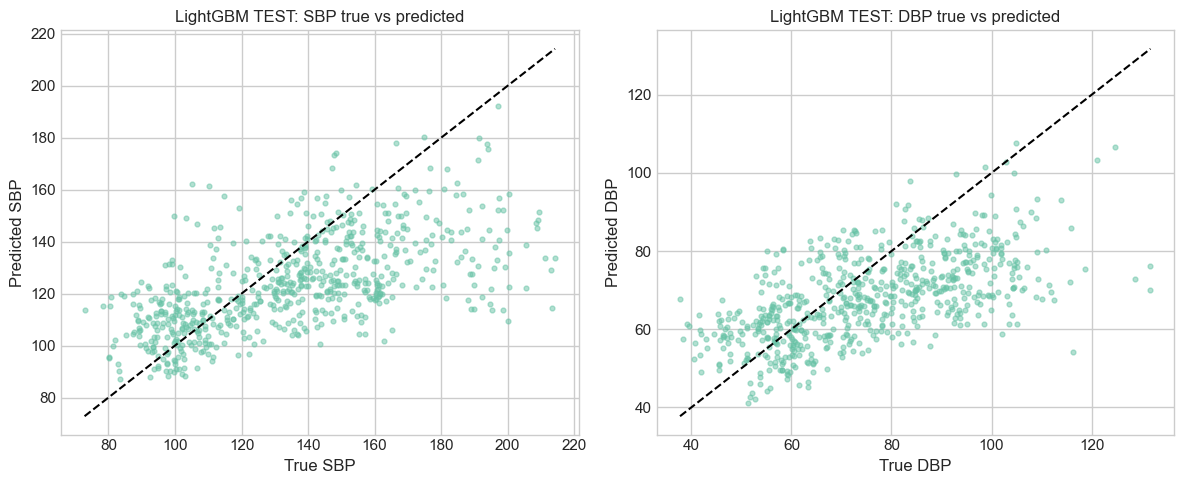

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test["SBP"], lgb_test_pred[:, 0], s=12, alpha=0.5)
axes[0].plot(
    [y_test["SBP"].min(), y_test["SBP"].max()],
    [y_test["SBP"].min(), y_test["SBP"].max()],
    "k--"
)
axes[0].set_xlabel("True SBP")
axes[0].set_ylabel("Predicted SBP")
axes[0].set_title("LightGBM TEST: SBP true vs predicted")

axes[1].scatter(y_test["DBP"], lgb_test_pred[:, 1], s=12, alpha=0.5)
axes[1].plot(
    [y_test["DBP"].min(), y_test["DBP"].max()],
    [y_test["DBP"].min(), y_test["DBP"].max()],
    "k--"
)
axes[1].set_xlabel("True DBP")
axes[1].set_ylabel("Predicted DBP")
axes[1].set_title("LightGBM TEST: DBP true vs predicted")

plt.tight_layout()
plt.show()

In [127]:
rf_test_pred = model.predict(X_test)

print("Random Forest TEST SBP MAE:", mean_absolute_error(y_test["SBP"], rf_test_pred[:, 0]))
print("Random Forest TEST DBP MAE:", mean_absolute_error(y_test["DBP"], rf_test_pred[:, 1]))

print("Random Forest TEST SBP RMSE:", mean_squared_error(y_test["SBP"], rf_test_pred[:, 0]) ** 0.5)
print("Random Forest TEST DBP RMSE:", mean_squared_error(y_test["DBP"], rf_test_pred[:, 1]) ** 0.5)

print("Random Forest TEST SBP ME:", np.mean(rf_test_pred[:, 0] - y_test["SBP"].values))
print("Random Forest TEST DBP ME:", np.mean(rf_test_pred[:, 1] - y_test["DBP"].values))

print("Random Forest TEST SBP SD Error:", np.std(rf_test_pred[:, 0] - y_test["SBP"].values))
print("Random Forest TEST DBP SD Error:", np.std(rf_test_pred[:, 1] - y_test["DBP"].values))

Random Forest TEST SBP MAE: 22.141927324063918
Random Forest TEST DBP MAE: 13.521778837522223
Random Forest TEST SBP RMSE: 28.54583864671893
Random Forest TEST DBP RMSE: 17.116387787319255
Random Forest TEST SBP ME: -13.584004621679842
Random Forest TEST DBP ME: -8.965301995791792
Random Forest TEST SBP SD Error: 25.106567317789438
Random Forest TEST DBP SD Error: 14.580606674968758


| algorithm     |   SBP_MAE |   DBP_MAE |
| ------------- | --------: | --------: |
| XGBoost       | **20.20** |     13.40 |
| LightGBM      |     20.31 | **13.02** |
| Random Forest |     22.14 |     13.52 |


Полученные результаты показывают, что классические модели демонстрируют приемлемое качество на валидационной выборке, однако их устойчивость существенно снижается при тестировании на независимом подмножестве с повышенными значениями артериального давления. Основной характер ошибки заключается в систематическом занижении SBP и DBP, что указывает на эффект регрессии к среднему и недостаточную представленность гипертензивных наблюдений в обучающем распределении.

Следовательно, при переходе к оценке давления по rPPG из видео лица необходимо уделить особое внимание не только архитектуре модели, но и балансировке обучающей выборки по диапазонам давления, subject-level split и отдельной проверке качества на high-pressure подмножестве.